In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
### Load the dataset

farm_data= pd.read_csv("classification_data.csv")

In [61]:
### create a duplicate
farm = farm_data.copy()

In [62]:
### Basic checks
farm.shape

(2200, 9)

In [63]:
farm.columns

Index(['Date', 'Region', 'Crop_Type', 'Rainfall_mm', 'Temperature_C',
       'Soil_Moisture', 'Fertilizer_Used', 'Pest_Presence',
       'Disease_Presence'],
      dtype='object')

In [64]:
farm.dtypes

Date                 object
Region               object
Crop_Type            object
Rainfall_mm         float64
Temperature_C       float64
Soil_Moisture       float64
Fertilizer_Used      object
Pest_Presence       float64
Disease_Presence    float64
dtype: object

In [65]:
### overview of the data
farm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              2200 non-null   object 
 1   Region            2188 non-null   object 
 2   Crop_Type         2183 non-null   object 
 3   Rainfall_mm       2185 non-null   float64
 4   Temperature_C     2179 non-null   float64
 5   Soil_Moisture     2184 non-null   float64
 6   Fertilizer_Used   2184 non-null   object 
 7   Pest_Presence     2195 non-null   float64
 8   Disease_Presence  2193 non-null   float64
dtypes: float64(5), object(4)
memory usage: 154.8+ KB


In [66]:
### check for missing values
farm.isnull().sum()

Date                 0
Region              12
Crop_Type           17
Rainfall_mm         15
Temperature_C       21
Soil_Moisture       16
Fertilizer_Used     16
Pest_Presence        5
Disease_Presence     7
dtype: int64

In [67]:
### Group numeric values only
num_farm=farm.select_dtypes(include="number").drop(columns=["Pest_Presence","Disease_Presence"])

### Exploratory Data Analysis

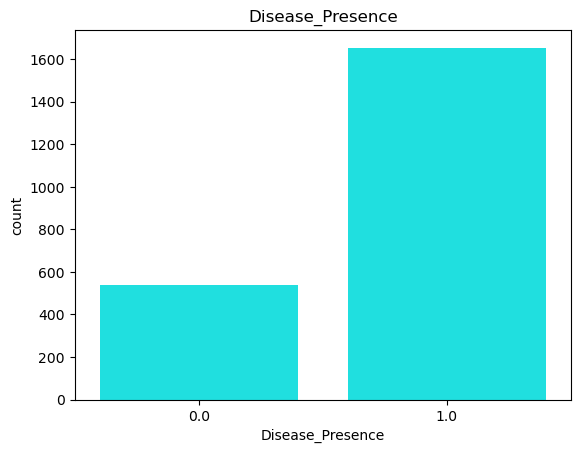

In [68]:
### Visualize the target Variable
farm["Disease_Presence"]
sns.countplot(x="Disease_Presence",data=farm,color="cyan")
plt.title("Disease_Presence")
plt.show()

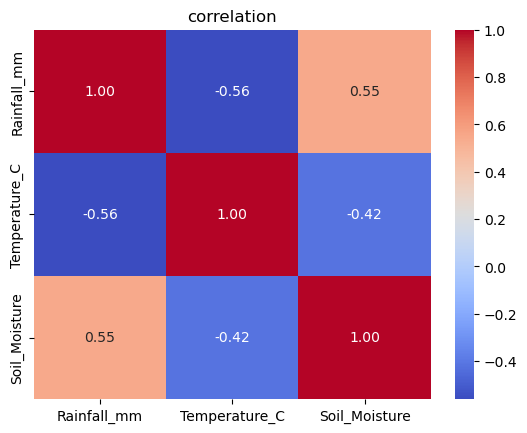

In [69]:
### visualize coeffiecient
sns.heatmap(num_farm.corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("correlation")
plt.show()

In [70]:
num_list=num_farm.columns.to_list()

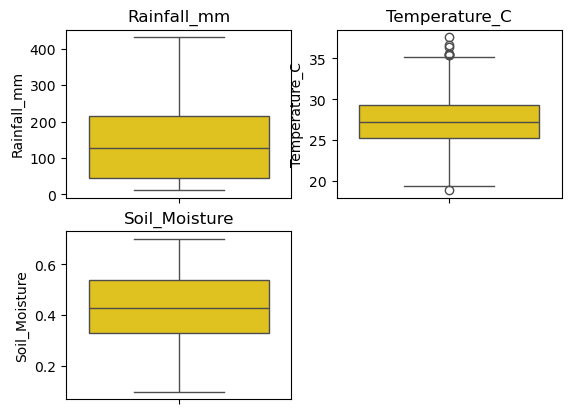

In [71]:
###Boxplot
for index,col in enumerate(num_list,start=1):
    plt.subplot(2,2,index)
    sns.boxplot(num_farm[col],color="gold")
    plt.title(col)
plt.title(col)
plt.show()
#sns boxplot

In [72]:
### IQR
container={}
for col in num_list:
    Q1=num_farm[col].quantile(0.25)
    Q3=num_farm[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    outliers=num_farm[(num_farm[col]<lower_bound)|(num_farm[col]>upper_bound)][col]
    container.update({col:outliers})

In [73]:
### unpack the dictionary
for item, value in container.items():
    print(f"{item}:{len(value)}outliers")

Rainfall_mm:0outliers
Temperature_C:8outliers
Soil_Moisture:0outliers


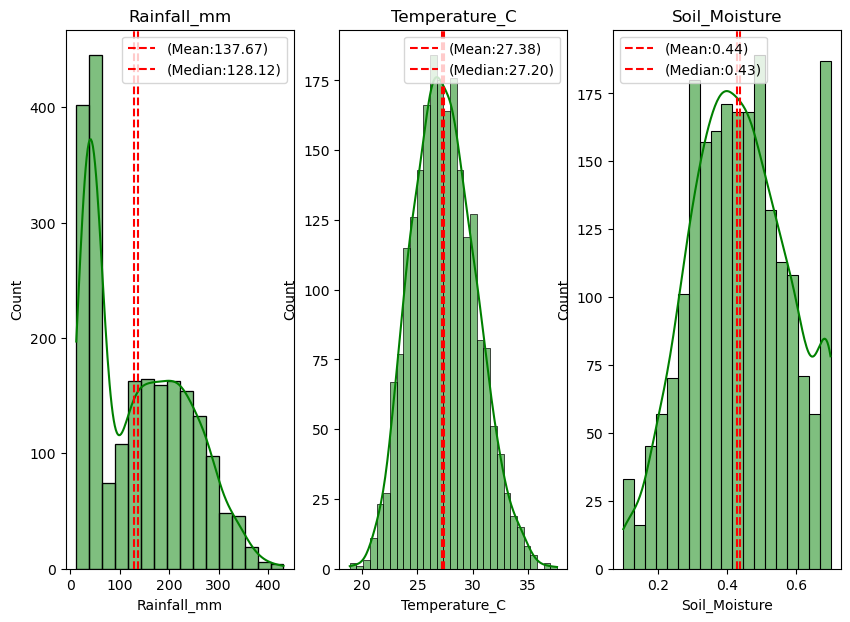

In [74]:
### Histogram plot
plt.figure(figsize=(10,7))
for index, col in enumerate(num_list,start=1):
    plt.subplot(1,3,index)
    sns.histplot(num_farm[col],kde=True,color="green")
    mean_line=num_farm[col].mean()
    median_line=num_farm[col].median()
    plt.axvline(mean_line,linestyle="--",color="red",label=f"(Mean:{mean_line:.2f})")
    plt.axvline(median_line,linestyle="--",color="red",label=f"(Median:{median_line:.2f})")
    plt.legend()
    plt.title(col)
plt.show()

In [75]:
farm.dtypes

Date                 object
Region               object
Crop_Type            object
Rainfall_mm         float64
Temperature_C       float64
Soil_Moisture       float64
Fertilizer_Used      object
Pest_Presence       float64
Disease_Presence    float64
dtype: object

### Feature Engineering


In [76]:
farm["Date"]=pd.to_datetime(farm["Date"],format="%m/%d/%Y")

In [77]:
print(farm["Date"].dtype)

datetime64[ns]


In [78]:
farm["Month"]=farm["Date"].dt.month ## generating the month column

In [79]:
 ## 1,2,3,....,12 dry season:1,2,3,11,12...... rainy:4,5,6,7,8,9,10
farm["season"]=farm["Month"].apply(lambda month:1 if 4<=month<= 10 else 0)

In [80]:
farm.columns

Index(['Date', 'Region', 'Crop_Type', 'Rainfall_mm', 'Temperature_C',
       'Soil_Moisture', 'Fertilizer_Used', 'Pest_Presence', 'Disease_Presence',
       'Month', 'season'],
      dtype='object')

### Feature Selection

In [81]:
### selecting the independent variables
##x=farm.drop(columns=["Date","Disease_Presence","Month"])
### select the target variable
##y=farm["Disease_Presence"]

In [82]:
### Exclude the missing values from the target variable
farm_notna = farm[farm["Disease_Presence"].notna()]
farm_na = farm[farm["Disease_Presence"].isna()]

In [83]:
x=farm_notna.drop(columns=["Date","Disease_Presence","Month"])
y=farm_notna["Disease_Presence"]

In [84]:
from sklearn.model_selection import train_test_split

In [85]:

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify = y)


In [86]:
print(x_train.shape)
print(x_test.shape)

(1754, 8)
(439, 8)


In [87]:
x_train.columns

Index(['Region', 'Crop_Type', 'Rainfall_mm', 'Temperature_C', 'Soil_Moisture',
       'Fertilizer_Used', 'Pest_Presence', 'season'],
      dtype='object')

In [88]:
### Group the objects and the numeric type
num_list=x_train.select_dtypes(include="number").drop(columns="Pest_Presence").columns.to_list()
### object data types
cat_list=x_train.select_dtypes(include = "object").columns.to_list()
pest_col =["Pest_Presence"]

In [89]:
x_train.isnull().sum()

Region              9
Crop_Type          12
Rainfall_mm         9
Temperature_C      13
Soil_Moisture      10
Fertilizer_Used    10
Pest_Presence       3
season              0
dtype: int64

### SMOTE (Synthetic Minority Oversampling Technique)

In [90]:
from imblearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [91]:
### Focus on the numeric part
num_steps=Pipeline([("impute",SimpleImputer(strategy="mean")),("scaling",StandardScaler())])
cat_steps=Pipeline([("impute",SimpleImputer(strategy="most_frequent")),
                    ("encode",OneHotEncoder(drop="first"))])
pest_steps = Pipeline([("impute", SimpleImputer(strategy = "most_frequent"))])

In [92]:
### use the columntransformer to identify and effect the changes to the columns
preprocessor=ColumnTransformer([("num_transform",num_steps,num_list),("cat_transform",cat_steps,cat_list),
                  ("pest_transform",pest_steps,pest_col)])

In [93]:
farm["Disease_Presence"].value_counts(normalize=True)

Disease_Presence
1.0    0.754218
0.0    0.245782
Name: proportion, dtype: float64

### Model Selection

In [94]:
### Logisticregression
##model_log=Pipeline([("column_transform",preprocessor),("smote",SMOTE(random_state=42)),
       # ("classifier",LogisticRegression())])
### Logistic regression
model_log = Pipeline([("column_transform", preprocessor), ("smote", SMOTE(random_state = 42)),("classifier", LogisticRegression())])

In [95]:
### training the model
model_log.fit(x_train,y_train)

,steps,"[('column_transform', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_transform', ...), ('cat_transform', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [96]:
### predict using the model
y_pred_log=model_log.predict(x_test)

### Evaluate the model

In [97]:
### use the classification report
print(classification_report(y_test,y_pred_log))

              precision    recall  f1-score   support

         0.0       0.39      0.70      0.50       108
         1.0       0.87      0.63      0.73       331

    accuracy                           0.65       439
   macro avg       0.63      0.67      0.62       439
weighted avg       0.75      0.65      0.68       439



In [98]:
### Precision 
### of all the positive predictions,how many of the positives were actually right
### precision=TP/(TP+FP)
### Falsepositive is termed as typer 1 error
## recall=TP/(TP+TN)

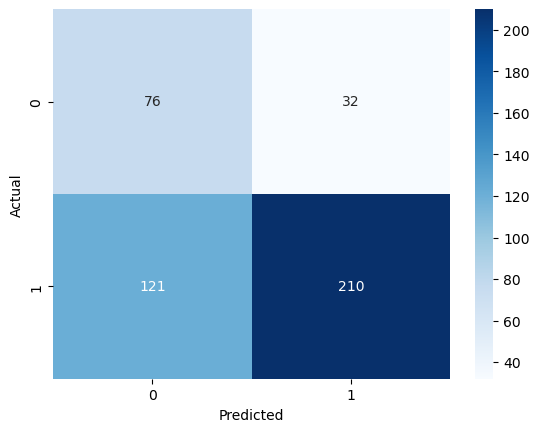

In [99]:
cm=confusion_matrix(y_test,y_pred_log)
### visualize on the heatmap
sns.heatmap(cm,annot=True,cmap="Blues",fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [100]:
### the 121 is called the FalseNegative(FN)
## Truepositive(Tp)=210
### Falsepositive(Fp)=32
### TrueNegative(TN)=76

In [101]:
precision=210/(210+32)
precision=round(precision,2)
recall=210/(210+121)
recall=round(recall,2)
(precision+recall)/2

0.75

### Decision Tree

In [102]:
from sklearn.tree import DecisionTreeClassifier

In [103]:
### Decision Tree
model_tree=Pipeline([("column_transform",preprocessor),("smote",SMOTE(random_state=42)),
          ("classifier", DecisionTreeClassifier())])

In [104]:
#### Fit the model
model_tree.fit(x_train, y_train)

,steps,"[('column_transform', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_transform', ...), ('cat_transform', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [105]:
### use it for prediction
y_pred_tree=model_tree.predict(x_test)

In [106]:
### Evaluating the model
print(accuracy_score(y_test,y_pred_tree))

0.6446469248291572


In [107]:
print(classification_report(y_test,y_pred_tree))

              precision    recall  f1-score   support

         0.0       0.33      0.42      0.37       108
         1.0       0.79      0.72      0.75       331

    accuracy                           0.64       439
   macro avg       0.56      0.57      0.56       439
weighted avg       0.68      0.64      0.66       439



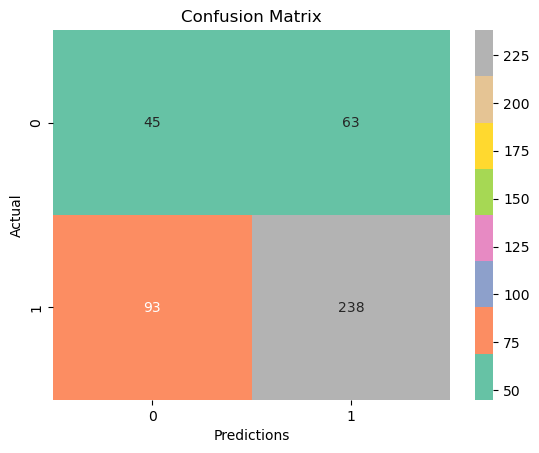

In [108]:
cm = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Set2")
plt.title("Confusion Matrix")
plt.xlabel("Predictions")
plt.ylabel("Actual")
plt.show()

## Random Forest

In [109]:
from sklearn.ensemble import RandomForestClassifier

In [110]:
### Random Forest
model_forest = Pipeline([("column_transform", preprocessor), ("smote", SMOTE(random_state = 42)),
          ("classifier", RandomForestClassifier())])

In [111]:
### fit the model
model_forest.fit(x_train,y_train)

,steps,"[('column_transform', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_transform', ...), ('cat_transform', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [112]:
### Predictions
y_pred_forest = model_forest.predict(x_test)

In [113]:
### Evaluate
print(accuracy_score(y_test, y_pred_forest))

0.7220956719817767


In [114]:
### Evaluating the model
print(accuracy_score(y_test,y_pred_forest))

0.7220956719817767


In [115]:
print(classification_report(y_test,y_pred_forest))

              precision    recall  f1-score   support

         0.0       0.44      0.50      0.47       108
         1.0       0.83      0.79      0.81       331

    accuracy                           0.72       439
   macro avg       0.64      0.65      0.64       439
weighted avg       0.73      0.72      0.73       439



### XGBoost

In [119]:
### Installing XGBOOST
pip install xgboost

SyntaxError: invalid syntax (1168277271.py, line 2)

In [118]:
from xgboost import XGBClassifier

In [120]:
### Intialize the model in the model
### Random Forest

model_xgb= Pipeline([("column_transform", preprocessor), ("smote", SMOTE(random_state = 42)),
          ("classifier", XGBClassifier())])

In [121]:
### fit the model
model_xgb.fit(x_train,y_train)

,steps,"[('column_transform', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_transform', ...), ('cat_transform', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [122]:
### Prediction
y_pred_xgb=model_xgb.predict(x_test)

In [123]:
### check the accuracy
print(accuracy_score(y_test,y_pred_xgb))

0.715261958997722


In [124]:
print(classification_report(y_test,y_pred_xgb))

              precision    recall  f1-score   support

         0.0       0.42      0.44      0.43       108
         1.0       0.81      0.81      0.81       331

    accuracy                           0.72       439
   macro avg       0.62      0.62      0.62       439
weighted avg       0.72      0.72      0.72       439



### Feature Importance

In [125]:
### using random forest
param_model=model_forest.named_steps["classifier"]

In [129]:
feature_names=model_forest.named_steps["column_transform"].get_feature_names_out()

In [130]:
coef=param_model.feature_importances_

In [131]:
feature_df = pd.DataFrame({"Features":feature_names,"Values": coef})
feature_df.head(4)

,Features,Values
0,num_transform__Rainfall_mm,0.224179
1,num_transform__Temperature_C,0.189701
2,num_transform__Soil_Moisture,0.206697
3,num_transform__season,0.026949


In [132]:
feature_df["Features"].str.split("_")

0              [num, transform, , Rainfall, mm]
1            [num, transform, , Temperature, C]
2            [num, transform, , Soil, Moisture]
3                    [num, transform, , season]
4     [cat, transform, , Region, Greater Accra]
5          [cat, transform, , Region, Northern]
6             [cat, transform, , Region, Volta]
7           [cat, transform, , Region, Western]
8         [cat, transform, , Crop, Type, Cocoa]
9         [cat, transform, , Crop, Type, Maize]
10         [cat, transform, , Crop, Type, Rice]
11          [cat, transform, , Crop, Type, Yam]
12    [cat, transform, , Fertilizer, Used, Yes]
13          [pest, transform, , Pest, Presence]
Name: Features, dtype: object

In [133]:
feature_df["Features"] = feature_df["Features"].str.split("__").str[1]

In [134]:
feature_df["Features"].unique()

array(['Rainfall_mm', 'Temperature_C', 'Soil_Moisture', 'season',
       'Region_Greater Accra', 'Region_Northern', 'Region_Volta',
       'Region_Western', 'Crop_Type_Cocoa', 'Crop_Type_Maize',
       'Crop_Type_Rice', 'Crop_Type_Yam', 'Fertilizer_Used_Yes',
       'Pest_Presence'], dtype=object)

In [135]:
feature_df["Features"] = feature_df["Features"].str.split("_").str[:2].str.join("_")

In [136]:
feature_df.loc[feature_df["Features"] == "Region_Northern", "Features"] = "Region"
feature_df.loc[feature_df["Features"] == "Region_Western", "Features"] = "Region"
feature_df.loc[feature_df["Features"] == "Region_Volta", "Features"] = "Region"
feature_df.loc[feature_df["Features"] == "Region_Greater Accra", "Features"] = "Region"

In [137]:
grouped_features = feature_df.groupby("Features")["Values"].sum().sort_values()

In [138]:
grouped_features = feature_df.groupby("Features")["Values"].sum().sort_values()

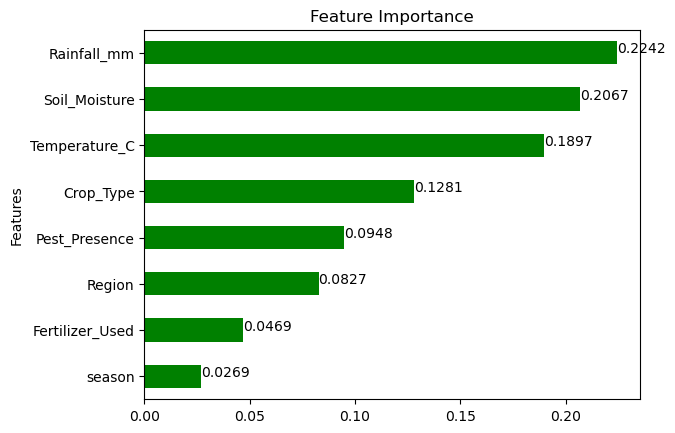

In [139]:
grouped_features.plot(kind = "barh", color = "g")
plt.title("Feature Importance")

### Add labels
for x, y in enumerate(grouped_features):
    plt.text(y, x, f"{y:.4f}")

plt.show()

In [ ]:
### Cross validation is a validation processs

### Cross Validation
- K-Fold Cross Validation

In [140]:
from sklearn.model_selection import cross_val_score,StratifiedKFold

In [141]:
### set up your cross validation
cross_validate=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [142]:
### Perform the training
scores=cross_val_score(model_forest,x_train,y_train,cv=cross_validate,scoring="f1")

In [143]:
### print the mean and standard deviation
print(f"Mean: {scores.mean()}")
print(f"Standard Deviation: {scores.std()}")

Mean: 0.8340454660799418
Standard Deviation: 0.01699134771579551


### Hyperparameter Tuning

### Grid Search Cross Validation

In [144]:
###Using the random forest on the best model
random_grid={"classifier_n_estimators":[50,100],
"classifier_max_depth":[3,5,None],
"classifier_min_samples_split":[2,5],
"classifier_min_samples_leaf":[1,2,5],
"classifier_class_weight":["balanced"]}

In [145]:
### using the rando forest on the best model 
from sklearn.model_selection import  GridSearchCV

In [146]:
search_grid=GridSearchCV(model_forest,param_grid=random_grid,cv=5,scoring="f1")

### ROC- AUC

In [153]:
from sklearn.metrics import roc_auc_score,roc_curve

In [150]:
y_proba=model_forest.predict_proba(x_test)[:,1]

In [151]:
print(roc_auc_score(y_test,y_proba))

0.7088928051918988


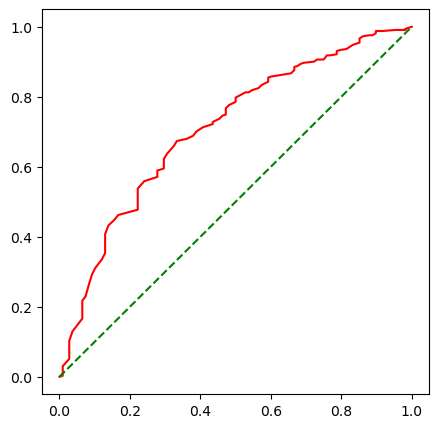

In [158]:
### visualize the Roc
TPR,FPR,threshold= roc_curve(y_test,y_proba)
plt.figure(figsize=(5,5))
plt.plot(TPR,FPR,color="r")
plt.plot([0,1],[0,1],linestyle="--",color="g")
plt.show()
